## **Retail Sales Analysis**

# Python + EDA + R Programming

Dataset: 5000 Transactions |Jan 2024-Dec 2024|



## **Project Objective**

This project aims to analyze retail sales data from January to December 2024 to identify key revenue drivers, understand customer purchasing behavior, and assess the impact of discounts. The insights derived will help inform strategic business decisions, optimize sales performance, and enhance customer satisfaction for future periods.

# Import Python


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# --- Diagnostic Code ---
# First, let's list all sheet names to find the correct one.
excel_file = pd.ExcelFile("retail_sales_dataset-1.xlsx")
print("Available sheets in Excel file:", excel_file.sheet_names)
# Assuming the main data is on a sheet named 'SalesData' or similar
# If a different sheet name is printed above, we'll update 'sheet_name'

# --- Original Load Data (modified) ---
df = pd.read_excel("retail_sales_dataset-1.xlsx", sheet_name='Retail', header=0) # Placeholder 'SalesData'

df['Profit'] = df['Final_Price'] - df['Total_Price'] # Commented out for diagnosis
df['Date'] = pd.to_datetime(df['Date']) # Commented out for diagnosis

print("✅ Setup Complete (for diagnosis)! Please check the sheet names.")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("First 5 rows:\n", df.head())

Available sheets in Excel file: ['Sheet1', 'Sheet2', 'Retail']
✅ Setup Complete (for diagnosis)! Please check the sheet names.
Shape: (5000, 20)
Columns: ['Transaction_ID', 'Date', 'Month', 'Day_of_Week', 'Store_ID', 'Region', 'Category', 'Product', 'Unit_Price', 'Quantity', 'Total_Price', 'Discount_Percent', 'Discount_Amount', 'Final_Price', 'Payment_Method', 'Customer_ID', 'Customer_Rating', 'Profit', 'Revenue', 'Discount Tier']
First 5 rows:
   Transaction_ID       Date     Month Day_of_Week   Store_ID Region  \
0      TXN_00001 2024-11-23  November    Saturday  STORE_042  South   
1      TXN_00002 2024-02-27  February     Tuesday  STORE_016   East   
2      TXN_00003 2024-01-13   January    Saturday  STORE_016  North   
3      TXN_00004 2024-05-20       May      Monday  STORE_032  North   
4      TXN_00005 2024-05-05       May      Sunday  STORE_040   East   

           Category     Product  Unit_Price  Quantity  Total_Price  \
0              Toys  Board Game      871.23         9

## EDA - Exploratory Data Analysis Using Python

In [ ]:
print("=" * 45)
print("        RETAIL SALES EDA REPORT")
print("=" * 45)

# Basic Info
print("\n📌 BASIC INFO")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

# Missing Values
print("\n📌 MISSING VALUES")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✅ No missing values found!")
else:
    print(missing)

# Data Types
print("\n📌 DATA TYPES")
print(df.dtypes)

# Statistical Summary
print("\n📌 STATISTICAL SUMMARY")
print(df.describe().round(2))

# Unique Values
print("\n📌 UNIQUE VALUES")
print("Regions:", df['Region'].unique().tolist())
print("Categories:", df['Category'].unique().tolist())
print("Payment:", df['Payment_Method'].unique().tolist())
print("Discounts:", sorted(df['Discount_Percent'].unique().tolist()))

# Key Metrics
print("\n📌 KEY BUSINESS METRICS")
print(f"Total Revenue: ₹{df['Final_Price'].sum():,.2f}")
print(f"Total Transactions: {len(df):,}")
print(f"Avg Order Value: ₹{df['Final_Price'].mean():,.2f}")
print(f"Total Quantity Sold: {df['Quantity'].sum():,}")
print(f"Avg Customer Rating: {df['Customer_Rating'].mean():.2f}")
print(f"Total Discount Given: ₹{df['Discount_Amount'].sum():,.2f}")

        RETAIL SALES EDA REPORT

📌 BASIC INFO
Total Rows: 5000
Total Columns: 19

📌 MISSING VALUES
✅ No missing values found!

📌 DATA TYPES
Transaction_ID              object
Date                datetime64[ns]
Month                       object
Day_of_Week                 object
Store_ID                    object
Region                      object
Category                    object
Product                     object
Unit_Price                 float64
Quantity                     int64
Total_Price                float64
Discount_Percent             int64
Discount_Amount            float64
Final_Price                float64
Payment_Method              object
Customer_ID                 object
Customer_Rating              int64
Discount Tier               object
Profit                     float64
dtype: object

📌 STATISTICAL SUMMARY
                             Date  Unit_Price  Quantity  Total_Price  \
count                        5000     5000.00   5000.00      5000.00   
mean   2024-07

Conveerting Excel to CSV

In [ ]:
import pandas as pd

# Ensure df is correctly loaded before converting to CSV
df = pd.read_excel("retail_sales_dataset-1.xlsx", sheet_name='Retail', header=0)

# Ensure 'Profit' and 'Date' columns are correctly processed
df['Profit'] = df['Final_Price'] - df['Total_Price']
df['Date'] = pd.to_datetime(df['Date'])

df.to_csv("retail_data.csv", index=False)
print("✅ Converted!")
print("Rows:", len(df))

✅ Converted!
Rows: 5000



# Python Visualization

Columns after loading:
 Index(['Transaction_ID', 'Date', 'Month', 'Day_of_Week', 'Store_ID', 'Region',
       'Category', 'Product', 'Unit_Price', 'Quantity', 'Total_Price',
       'Discount_Percent', 'Discount_Amount', 'Final_Price', 'Payment_Method',
       'Customer_ID', 'Customer_Rating', 'Profit', 'Revenue', 'Discount Tier'],
      dtype='object')
First 5 rows after loading:
   Transaction_ID       Date     Month Day_of_Week   Store_ID Region  \
0      TXN_00001 2024-11-23  November    Saturday  STORE_042  South   
1      TXN_00002 2024-02-27  February     Tuesday  STORE_016   East   
2      TXN_00003 2024-01-13   January    Saturday  STORE_016  North   
3      TXN_00004 2024-05-20       May      Monday  STORE_032  North   
4      TXN_00005 2024-05-05       May      Sunday  STORE_040   East   

           Category     Product  Unit_Price  Quantity  Total_Price  \
0              Toys  Board Game      871.23         9      7841.07   
1  Food & Beverages   Chocolate      441.24      

/tmp/ipykernel_2193/3297549440.py:104: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2193/3297549440.py:105: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig('retail_python_charts.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


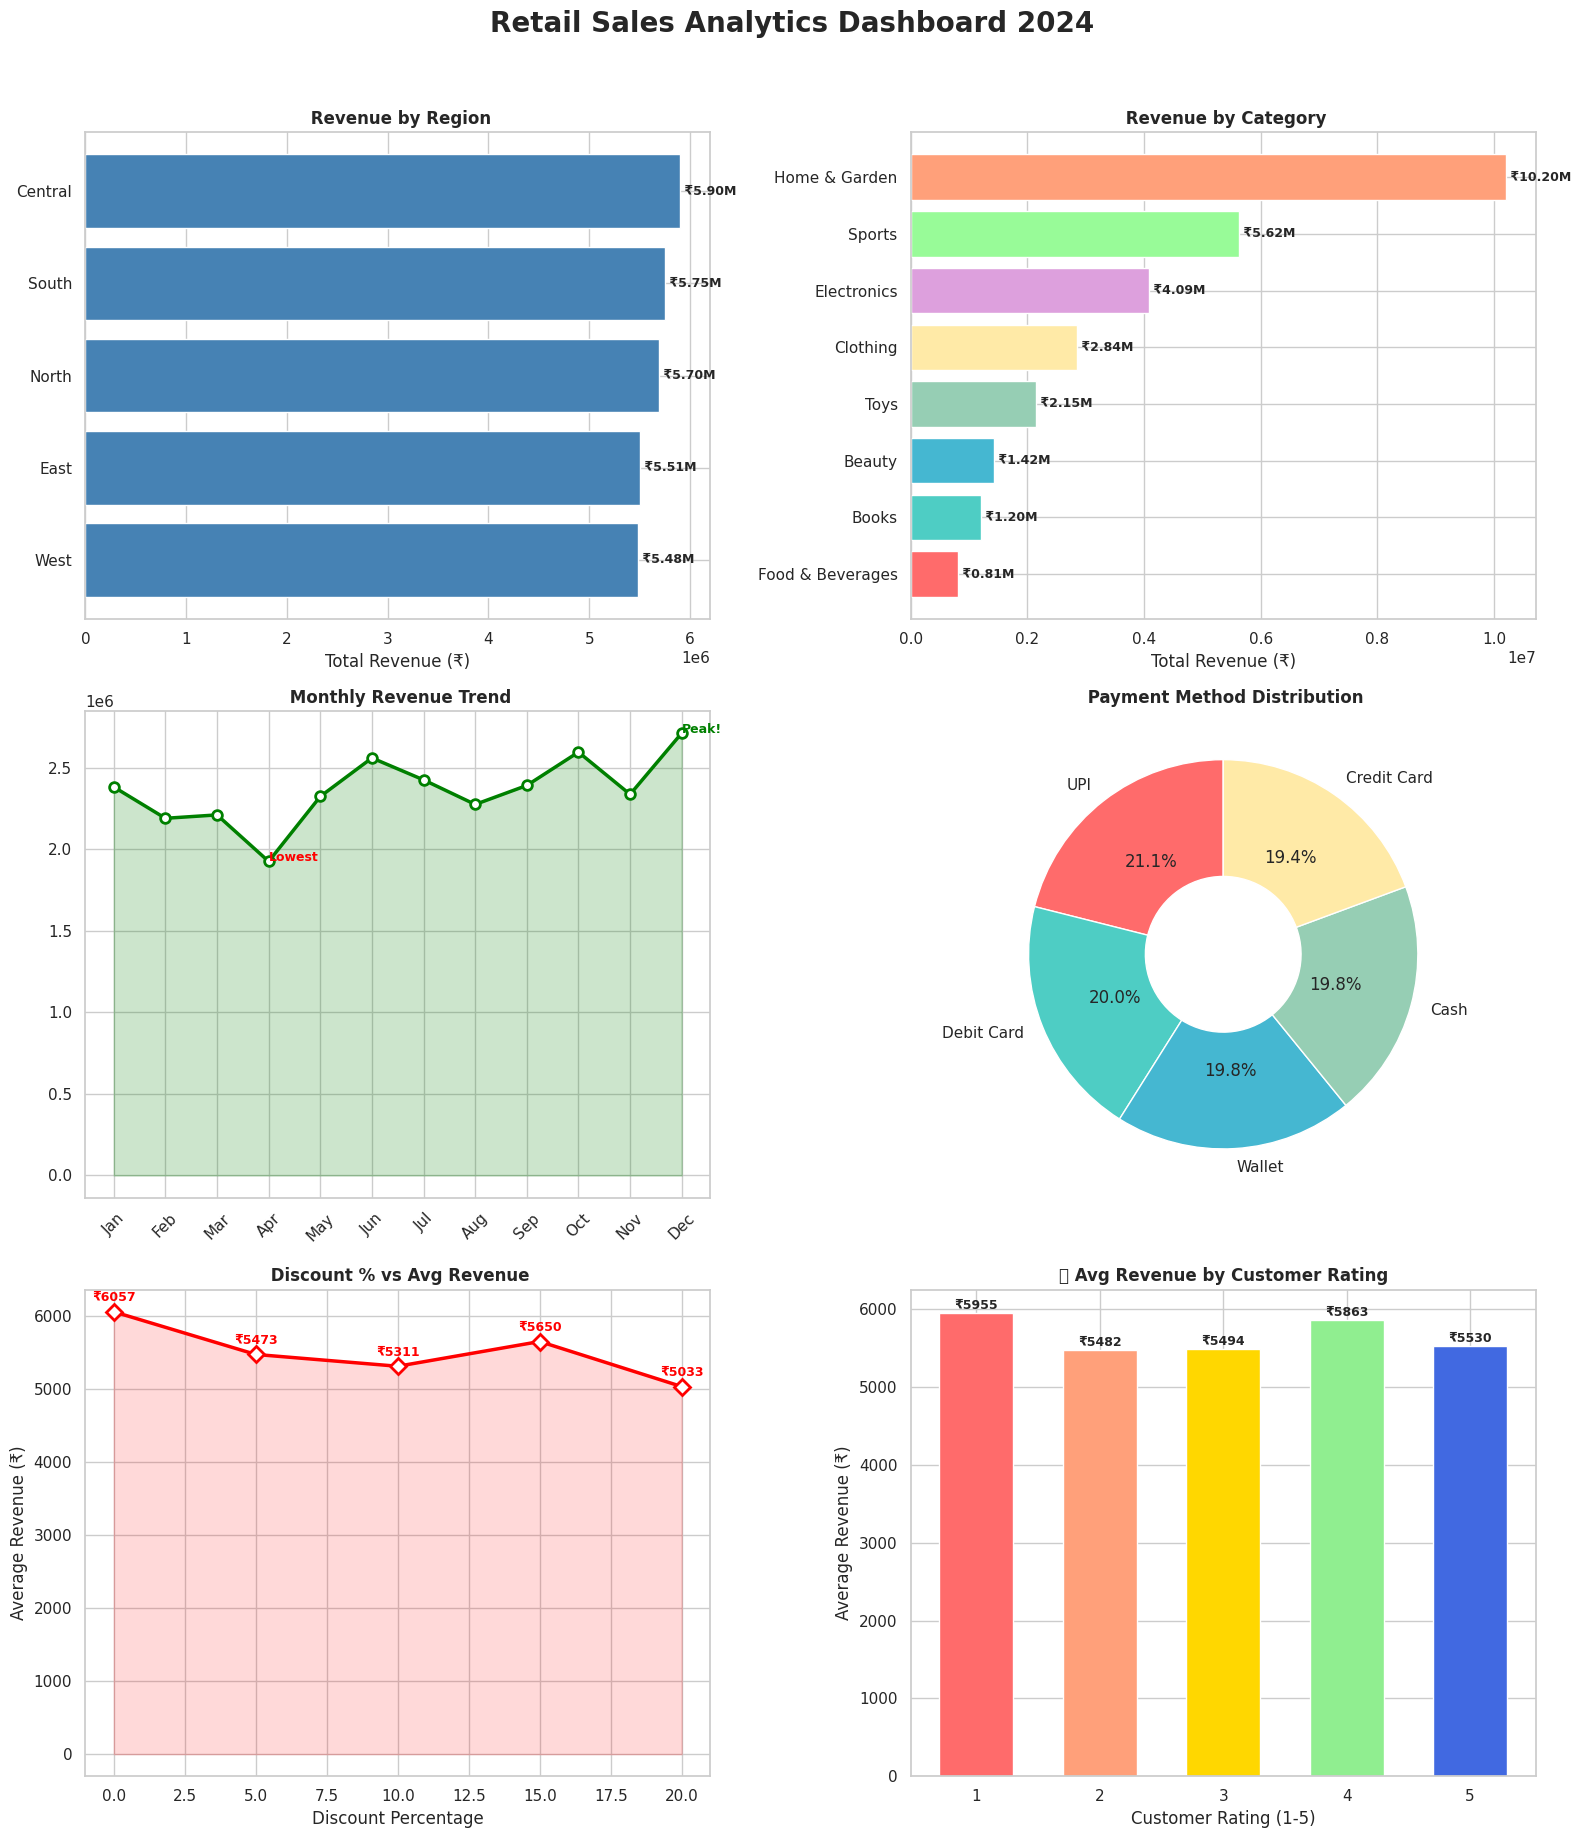

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data directly from the Excel file with the correct sheet
df = pd.read_excel("retail_sales_dataset-1.xlsx", sheet_name='Retail', header=0)

# Ensure 'Profit' and 'Date' columns are correctly processed
df['Profit'] = df['Final_Price'] - df['Total_Price']
df['Date'] = pd.to_datetime(df['Date'])

print("Columns after loading:\n", df.columns)
print("First 5 rows after loading:\n", df.head())

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Retail Sales Analytics Dashboard 2024',
             fontsize=20, fontweight='bold', y=1.02)

# ── Chart 1 — Revenue by Region ──
region_rev = df.groupby('Region')['Final_Price'].sum().sort_values(ascending=True)
axes[0,0].barh(region_rev.index, region_rev.values, color='steelblue', edgecolor='white')
axes[0,0].set_title(' Revenue by Region', fontweight='bold', fontsize=12)
axes[0,0].set_xlabel('Total Revenue (₹)')
for i, v in enumerate(region_rev.values):
    axes[0,0].text(v, i, f' ₹{v/1e6:.2f}M', va='center', fontsize=9, fontweight='bold')

# ── Chart 2 — Revenue by Category ──
cat_rev = df.groupby('Category')['Final_Price'].sum().sort_values(ascending=True)
colors_cat = ['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4',
              '#FFEAA7','#DDA0DD','#98FB98','#FFA07A']
bars_cat = axes[0,1].barh(cat_rev.index, cat_rev.values,
               color=colors_cat, edgecolor='white')
axes[0,1].set_title(' Revenue by Category', fontweight='bold', fontsize=12)
axes[0,1].set_xlabel('Total Revenue (₹)')
for bar in bars_cat:
    axes[0,1].text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                   f' ₹{bar.get_width()/1e6:.2f}M', va='center', ha='left', fontsize=9, fontweight='bold')

# ── Chart 3 — Monthly Trend ──
month_order = ['January','February','March','April',
               'May','June','July','August',
               'September','October','November','December']
monthly = df.groupby('Month')['Final_Price'].sum().reindex(month_order)
axes[1,0].plot(range(12), monthly.values,
               color='green', linewidth=2.5,
               marker='o', markersize=7,
               markerfacecolor='white', markeredgewidth=2)
axes[1,0].fill_between(range(12), monthly.values, alpha=0.2, color='green')
axes[1,0].set_title(' Monthly Revenue Trend', fontweight='bold', fontsize=12)
axes[1,0].set_xticks(range(12))
axes[1,0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                            'Jul','Aug','Sep','Oct','Nov','Dec'],
                            rotation=45)
# Mark highest and lowest
peak_idx = monthly.values.argmax()
low_idx = monthly.values.argmin()
axes[1,0].annotate('Peak!',
                   xy=(peak_idx, monthly.values[peak_idx]),
                   color='green', fontweight='bold', fontsize=9)
axes[1,0].annotate('Lowest',
                   xy=(low_idx, monthly.values[low_idx]),
                   color='red', fontweight='bold', fontsize=9)

# ── Chart 4 — Payment Method ──
payment = df['Payment_Method'].value_counts()
pie_colors = ['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7']
axes[1,1].pie(payment.values,
              labels=payment.index,
              autopct='%1.1f%%',
              colors=pie_colors,
              wedgeprops=dict(width=0.6, edgecolor='white'),
              startangle=90)
axes[1,1].set_title(' Payment Method Distribution',
                     fontweight='bold', fontsize=12)

# ── Chart 5 — Discount Impact ──
discount = df.groupby('Discount_Percent')['Final_Price'].mean()
axes[2,0].plot(discount.index, discount.values,
               color='red', linewidth=2.5,
               marker='D', markersize=8,
               markerfacecolor='white', markeredgewidth=2)
axes[2,0].fill_between(discount.index, discount.values,
                        alpha=0.15, color='red')
axes[2,0].set_title(' Discount % vs Avg Revenue',
                     fontweight='bold', fontsize=12)
axes[2,0].set_xlabel('Discount Percentage')
axes[2,0].set_ylabel('Average Revenue (₹)')
for x, y in zip(discount.index, discount.values):
    axes[2,0].text(x, y + 100, f'₹{y:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='red')

# ── Chart 6 — Rating vs Revenue ──
rating = df.groupby('Customer_Rating')['Final_Price'].mean()
bar_colors = ['#FF6B6B','#FFA07A','#FFD700','#90EE90','#4169E1']
bars = axes[2,1].bar(rating.index, rating.values,
                      color=bar_colors, edgecolor='white', width=0.6)
axes[2,1].set_title('⭐ Avg Revenue by Customer Rating',
                     fontweight='bold', fontsize=12)
axes[2,1].set_xlabel('Customer Rating (1-5)')
axes[2,1].set_ylabel('Average Revenue (₹)')
for bar, val in zip(bars, rating.values):
    axes[2,1].text(bar.get_x()+bar.get_width()/2,
                   val + 50, f'₹{val:.0f}',
                   ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('retail_python_charts.png', dpi=150, bbox_inches='tight')
plt.show()

# Install R Programming

In [ ]:

# First install rpy2
!pip install rpy2 -q

In [ ]:

%load_ext rpy2.ipython
print("✅ R is ready!")

✅ R is ready!


In [ ]:
display(df.describe())

,Date,Unit_Price,Quantity,Total_Price,Discount_Percent,Discount_Amount,Final_Price,Customer_Rating
count,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2024-07-03 18:55:17.760000,1078.933868,5.602000,6104.473268,6.981000,437.052922,5667.420346,2.992800
min,2024-01-01 00:00:00,50.320000,1.000000,54.570000,0.000000,0.000000,53.730000,1.000000
25%,2024-04-02 00:00:00,380.507500,3.000000,1602.095000,0.000000,0.000000,1477.920000,2.000000
50%,2024-07-04 00:00:00,686.920000,6.000000,3497.915000,5.000000,77.220000,3240.830000,3.000000
75%,2024-10-04 00:00:00,1408.487500,8.000000,7492.457500,15.000000,459.735000,6947.640000,4.000000
max,2024-12-31 00:00:00,4992.360000,10.000000,49796.100000,20.000000,9959.220000,48874.500000,5.000000
std,NaN,1037.279905,2.864478,7377.149361,7.464702,913.980195,6866.931771,1.408384


In [ ]:
%%R
df_r <- read.csv("/content/retail_data.csv")

cat("=== RETAIL SALES R ANALYSIS ===\n")
cat("Total Rows:", nrow(df_r), "\n")
cat("Total Columns:", ncol(df_r), "\n")

df_r$Profit <- df_r$Final_Price - df_r$Total_Price

cat("\n=== REVENUE SUMMARY ===\n")
print(summary(df_r$Final_Price))

cat("\n=== REVENUE BY REGION ===\n")
region <- aggregate(Final_Price ~ Region,
                    data=df_r, FUN=sum)
region <- region[order(-region$Final_Price),]
print(region)

cat("\n=== REVENUE BY CATEGORY ===\n")
category <- aggregate(Final_Price ~ Category,
                      data=df_r, FUN=sum)
category <- category[order(-category$Final_Price),]
print(category)

=== RETAIL SALES R ANALYSIS ===
Total Rows: 5000 
Total Columns: 20 

=== REVENUE SUMMARY ===
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
   53.73  1477.92  3240.83  5667.42  6947.64 48874.50 

=== REVENUE BY REGION ===
   Region Final_Price
1 Central     5903851
4   South     5747346
3   North     5695429
2    East     5506561
5    West     5483915

=== REVENUE BY CATEGORY ===
          Category Final_Price
6    Home & Garden  10202037.1
7           Sports   5621150.9
4      Electronics   4088247.0
3         Clothing   2842599.3
8             Toys   2148944.5
1           Beauty   1422706.0
2            Books   1201312.7
5 Food & Beverages    810104.3


# R Plotting

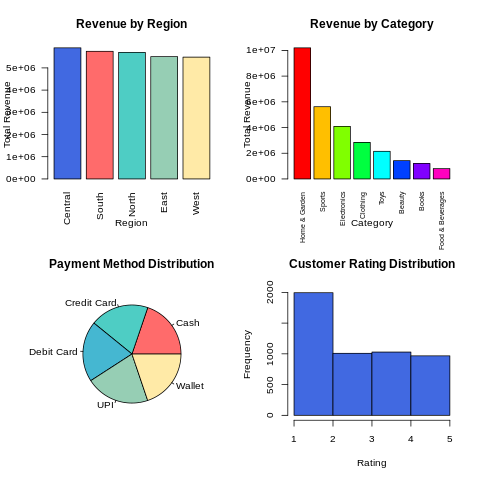

In [ ]:
%%R
# Set up plotting area
par(mfrow=c(2,2), mar=c(5,4,4,2))

# Chart 1 — Revenue by Region
region <- aggregate(Final_Price ~ Region,
                    data=df_r, FUN=sum)
region <- region[order(-region$Final_Price),]
barplot(region$Final_Price,
        names.arg=region$Region,
        col=c("#4169E1","#FF6B6B","#4ECDC4",
              "#96CEB4","#FFEAA7"),
        main="Revenue by Region",
        xlab="Region",
        ylab="Total Revenue",
        las=2)

# Chart 2 — Revenue by Category
category <- aggregate(Final_Price ~ Category,
                      data=df_r, FUN=sum)
category <- category[order(-category$Final_Price),]
barplot(category$Final_Price,
        names.arg=category$Category,
        col=rainbow(8),
        main="Revenue by Category",
        xlab="Category",
        ylab="Total Revenue",
        las=2,
        cex.names=0.7)

# Chart 3 — Payment Method
payment <- table(df_r$Payment_Method)
pie(payment,
    col=c("#FF6B6B","#4ECDC4",
          "#45B7D1","#96CEB4","#FFEAA7"),
    main="Payment Method Distribution")

# Chart 4 — Customer Rating Distribution
hist(df_r$Customer_Rating,
     col="#4169E1",
     main="Customer Rating Distribution",
     xlab="Rating",
     ylab="Frequency",
     breaks=5)

## R Statistical Analysis

In [ ]:
%%R
cat("=== CORRELATION ANALYSIS ===\n")
# Correlation between numeric columns
numeric_cols <- df_r[,c("Final_Price",
                         "Quantity",
                         "Unit_Price",
                         "Discount_Amount",
                         "Customer_Rating")]
print(cor(numeric_cols))

cat("\n=== DISCOUNT IMPACT ===\n")
discount <- aggregate(Final_Price ~ Discount_Percent,
                      data=df_r, FUN=mean)
print(discount)

cat("\n=== TOP 5 PERFORMING REGIONS ===\n")
region_summary <- aggregate(
    cbind(Final_Price, Quantity) ~ Region,
    data=df_r, FUN=sum)
region_summary <- region_summary[
    order(-region_summary$Final_Price),]
print(region_summary)

cat("\n=== MONTHLY REVENUE ===\n")
monthly <- aggregate(Final_Price ~ Month,
                     data=df_r, FUN=sum)
monthly <- monthly[order(-monthly$Final_Price),]
print(monthly)

cat("\n=== KEY INSIGHTS ===\n")
cat("Highest Revenue Region:",
    as.character(region_summary$Region[1]), "\n")
cat("Total Revenue: ₹",
    sum(df_r$Final_Price), "\n")
cat("Average Order Value: ₹",
    mean(df_r$Final_Price), "\n")
cat("Total Transactions:",
    nrow(df_r), "\n")

=== CORRELATION ANALYSIS ===
                 Final_Price    Quantity  Unit_Price Discount_Amount
Final_Price      1.000000000 0.438390739  0.80079843      0.51242634
Quantity         0.438390739 1.000000000  0.02029364      0.25188700
Unit_Price       0.800798425 0.020293639  1.00000000      0.49194484
Discount_Amount  0.512426336 0.251886999  0.49194484      1.00000000
Customer_Rating -0.009565509 0.005785181 -0.01244797     -0.02274088
                Customer_Rating
Final_Price        -0.009565509
Quantity            0.005785181
Unit_Price         -0.012447969
Discount_Amount    -0.022740878
Customer_Rating     1.000000000

=== DISCOUNT IMPACT ===
  Discount_Percent Final_Price
1                0    6056.708
2                5    5472.560
3               10    5310.835
4               15    5649.678
5               20    5032.729

=== TOP 5 PERFORMING REGIONS ===
   Region Final_Price Quantity
1 Central     5903851     5656
4   South     5747346     5463
3   North     5695429     5

## Export Clean Dataset

In [ ]:
# Save clean CSV
df.to_csv("retail_sales_clean.csv", index=False)
print("✅ Clean dataset saved!")
print("File: retail_sales_clean.csv")
print("Rows:", len(df))
print("Columns:", len(df.columns))

✅ Clean dataset saved!
File: retail_sales_clean.csv
Rows: 5000
Columns: 18


# 🔑 Key Findings from Retail Sales Data

Based on the comprehensive analysis using both Python and R, several key insights have emerged from the retail sales dataset:

# 1. 💰 Revenue Performance:
👑 Category Dominance: 'Home & Garden' is the overwhelming leader in total revenue, significantly outperforming all other categories. 'Sports' and 'Electronics' also contribute substantially, while 'Food & Beverages' generates the least revenue.

🗺️ Regional Contribution: The 'Central', 'South', and 'North' regions consistently show higher total revenue compared to 'West' and 'East'.

📈 Monthly Trends: Sales peak towards the end of the year, particularly in December and October, with June also showing strong performance. April appears to be the month with the lowest revenue, suggesting potential seasonal patterns or marketing opportunities.

🛍️ Customer & Transaction Behavior:
💳 Payment Methods: Payment methods are relatively evenly distributed, with UPI being slightly more popular, indicating a diverse customer preference for transactions.

🏷️ Discount Impact: Higher discount percentages generally correlate with a decrease in average revenue per transaction. This suggests that while discounts might drive volume, they can also reduce the overall value of individual sales.

⭐ Customer Rating vs. Revenue: Customer rating shows a very weak correlation with Final_Price, implying that average revenue is not strongly driven by how customers rate their experience.

# 2.🔗 Correlations & Relationships (from R Analysis):
A strong positive correlation exists between Final_Price and Unit_Price (0.80), and a moderate positive correlation with Quantity (0.44), which is expected as more expensive items and higher quantities naturally lead to higher final prices.

There's a positive correlation between Final_Price and Discount_Amount (0.51), which might seem counter-intuitive but suggests that larger absolute discount amounts are applied to transactions that are already high in total value.

Customer Rating has negligible correlation with other numerical metrics, reinforcing the observation from Python visualizations that it doesn't significantly impact other financial aspects directly.

# 3.✅ Overall:

The dataset shows a healthy volume of transactions with no missing values, providing a robust foundation for analysis.
These findings can guide strategic decisions, such as targeted marketing efforts for specific categories or regions, optimization of discount strategies, and seasonal inventory planning.